# Proyecto ML: Prediccion de la Direccion Diaria de Bitcoin

Bootcamp de Data Science | Clasificacion binaria supervisada sobre serie temporal.

Objetivo general: estimar la probabilidad de que Bitcoin cierre en positivo en el siguiente dia.


## Paso 1: Entendiendo el problema de negocio

- **Pregunta de negocio**: dada la informacion diaria disponible hasta el cierre del dia `t`, predecir si el retorno del dia `t+1` sera positivo.
- **Variable objetivo (target)**: `y_{t+1} = 1` si `ret_{t+1} > 0`, en otro caso `0` (incluye retorno cero y negativo).
- **Salida del modelo**: probabilidad `P(y_{t+1}=1 | X_t)` para apoyar decisiones de exposicion direccional.
- **Unidad de observacion**: un dia de mercado.
- **Restriccion critica de metodologia**: al ser serie temporal, la separacion train/test debe ser cronologica (sin shuffle) para evitar leakage.
- **Metricas esperadas**: ROC-AUC como metrica principal por evaluar ranking probabilistico sin fijar umbral desde el inicio.


In [24]:
# Imports base del proyecto
from __future__ import annotations

import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

print("Imports cargados correctamente")


Imports cargados correctamente


## Paso 2: Carga y validacion inicial del dataset

En este paso preparamos la estructura temporal del dataset. Todavia no se construye el target.

> Control de leakage: solo hacemos parseo de fecha, orden cronologico e indice temporal; no usamos informacion futura.


In [ ]:
# Carga del CSV
from pathlib import Path
import pandas as pd

DATA_PATH = Path("src/data_sample/Bitcoin_history_data.csv")
df = pd.read_csv(DATA_PATH)

# 1) Date a datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# 2) Orden cronologico
df = df.sort_values("Date").reset_index(drop=True)

# 3) Indice temporal
df = df.set_index("Date")

print(f"Dataset cargado desde: {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head(3)


Dataset cargado desde: src/data_sample/Bitcoin_history_data.csv
Shape: (4175, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700


### Validaciones requeridas por el enunciado

Comprobamos: rango de fechas, numero de filas, missing values, tipos de datos, duplicados por fecha y orden temporal.


In [26]:
# Validacion basica del dataset
date_min, date_max = df.index.min(), df.index.max()
n_rows = len(df)
n_missing_total = int(df.isna().sum().sum())
n_duplicated_dates = int(df.index.duplicated().sum())
is_sorted = bool(df.index.is_monotonic_increasing)

print(f"Rango de fechas: {date_min.date()} -> {date_max.date()}")
print(f"Numero de filas: {n_rows}")
print(f"Missing values totales: {n_missing_total}")
print(f"Fechas duplicadas en indice: {n_duplicated_dates}")
print(f"Indice temporal ordenado ascendente: {is_sorted}")

display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("missing_count").T)


Rango de fechas: 2014-09-17 -> 2026-02-20
Numero de filas: 4175
Missing values totales: 0
Fechas duplicadas en indice: 0
Indice temporal ordenado ascendente: True


,dtype
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


,Close,High,Low,Open,Volume
missing_count,0,0,0,0,0


## Paso 3: Construccion del target sin data leakage

Definimos el target con el retorno de cierre del dia siguiente (`t+1`). Es el unico punto donde se usa `shift(-1)` y solo para etiquetar.

> Control de leakage: la columna intermedia con retorno futuro se elimina antes de seguir, para que nunca entre como feature del modelo.


In [ ]:
# Construccion de target: 1 si retorno de t+1 > 0, 0 en caso contrario
df_target = df.copy()
# Retorno del dia siguiente asociado al dia t
df_target["ret_next_day"] = df_target["Close"].pct_change().shift(-1)
# Etiqueta binaria con NaN en la ultima fila (no existe t+1)
df_target["target"] = np.where(
    df_target["ret_next_day"].isna(),
    np.nan,
    (df_target["ret_next_day"] > 0).astype(int),
)
# Dataset final sin variable futura
df = df_target.drop(columns=["ret_next_day"]).dropna(subset=["target"]).copy()
df["target"] = df["target"].astype(int)

print(f"Filas originales: {len(df_target)}")
print(f"Filas con target disponible: {len(df)}")
print(f"Filas descartadas por no tener t+1: {len(df_target) - len(df)}")
print(f"ret_next_day presente en df final: {'ret_next_day' in df.columns}")

display(df_target[["Close", "ret_next_day", "target"]].tail(3))
display(df["target"].value_counts().to_frame("count").T)
display((df["target"].value_counts(normalize=True) * 100).round(2).to_frame("pct").T)


Filas originales: 4175
Filas con target disponible: 4174
Filas descartadas por no tener t+1: 1
ret_next_day presente en df final: False


,Close,ret_next_day,target
Date,,,
2026-02-18,66425.320312,0.008012,1.0
2026-02-19,66957.523438,0.015650,1.0
2026-02-20,68005.421875,NaN,NaN


target,1,0
count,2192,1982


target,1,0
pct,52.52,47.48


## Paso 4: Mini EDA dirigido al modelado

Este EDA es breve y orientado a decisiones de modelado: entender escala de variables, equilibrio de clases y estabilidad temporal del target.

> Control de leakage: solo analisis descriptivo; no hay ajuste de transformaciones ni entrenamiento.


In [28]:
# Panorama general para modelado
numeric_cols = ["Open", "High", "Low", "Close", "Volume"]

print(f"Filas utiles para modelado: {len(df)}")
print(f"Rango temporal util: {df.index.min().date()} -> {df.index.max().date()}")

display(df[numeric_cols].describe().T)
display(df[numeric_cols + ["target"]].isna().sum().to_frame("missing_count").T)


Filas utiles para modelado: 4174
Rango temporal util: 2014-09-17 -> 2026-02-19


,count,mean,std,min,25%,50%,75%,max
Open,4174.0,2.750144e+04,3.205916e+04,1.768970e+02,2.806952e+03,1.097785e+04,4.302425e+04,1.247521e+05
High,4174.0,2.805011e+04,3.260090e+04,2.117310e+02,2.897920e+03,1.133500e+04,4.383192e+04,1.261981e+05
Low,4174.0,2.691388e+04,3.146913e+04,1.715100e+02,2.691330e+03,1.066830e+04,4.219030e+04,1.231960e+05
Close,4174.0,2.751636e+04,3.206156e+04,1.781030e+02,2.806468e+03,1.097703e+04,4.306282e+04,1.247525e+05
Volume,4174.0,2.192279e+10,2.302278e+10,5.914570e+06,1.381632e+09,1.727397e+10,3.371901e+10,3.509679e+11


,Open,High,Low,Close,Volume,target
missing_count,0,0,0,0,0,0


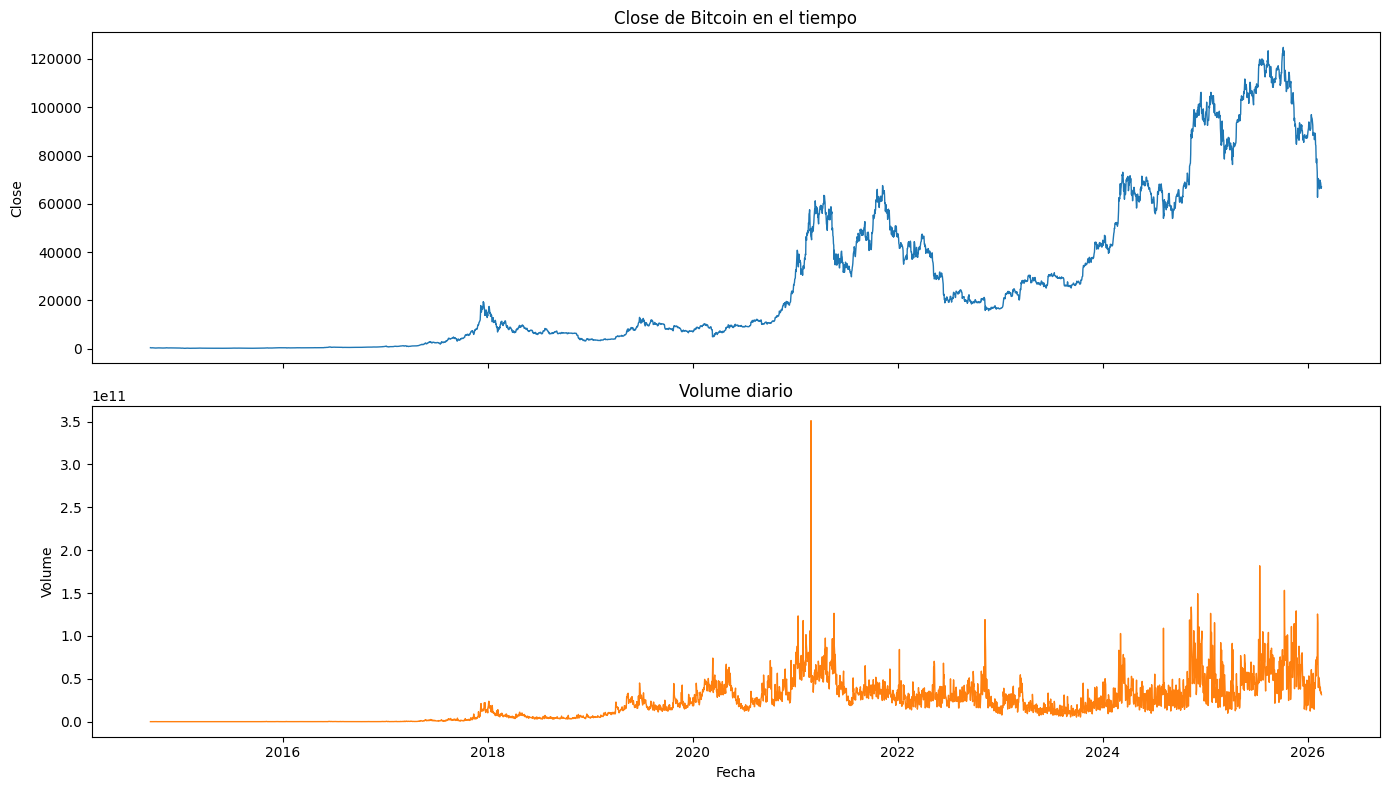

,pct_target_1,n_dias
Date,,
2017-12-31,61.10,365
2018-12-31,51.23,365
2019-12-31,52.33,365
2020-12-31,56.28,366
2021-12-31,51.23,365
2022-12-31,46.58,365
2023-12-31,49.86,365
2024-12-31,52.19,366
2025-12-31,49.86,365


In [29]:
# Evolucion temporal de precio/volumen y del target
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["Close"], color="tab:blue", linewidth=1)
axes[0].set_title("Close de Bitcoin en el tiempo")
axes[0].set_ylabel("Close")

axes[1].plot(df.index, df["Volume"], color="tab:orange", linewidth=1)
axes[1].set_title("Volume diario")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

target_yearly = df["target"].resample("YE").agg(["mean", "count"])
target_yearly = target_yearly.rename(columns={"mean": "pct_target_1", "count": "n_dias"})
target_yearly["pct_target_1"] = (target_yearly["pct_target_1"] * 100).round(2)
display(target_yearly.tail(10))


,spearman_corr_vs_target
Close,-0.046364
Low,-0.045348
High,-0.045296
Open,-0.044442
Volume,-0.035020


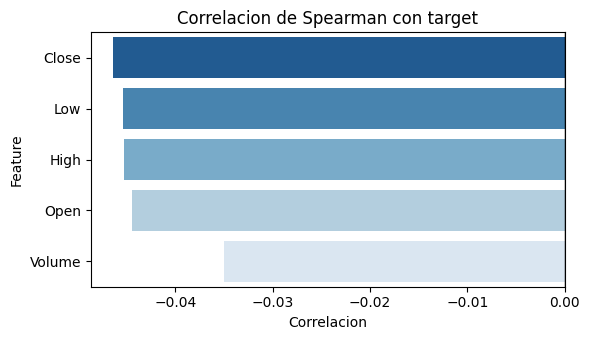

In [30]:
# Relacion simple feature-target (orientativa para el siguiente paso)
corr_target = (
    df[numeric_cols + ["target"]]
    .corr(method="spearman")["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(corr_target.to_frame("spearman_corr_vs_target"))

plt.figure(figsize=(6, 3.5))
sns.barplot(x=corr_target.values, y=corr_target.index, orient="h", palette="Blues_r")
plt.axvline(0, color="black", linewidth=1)
plt.title("Correlacion de Spearman con target")
plt.xlabel("Correlacion")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Paso 4.5: Feature Engineering sencillo (sin leakage)

Creamos variables tecnicas basicas usando solo informacion disponible hasta el cierre del dia `t`.

> Control de leakage: no se usan desplazamientos hacia el futuro en las features (solo historico/rolling hacia atras).


In [31]:
# Features base + engineered (version simple)
base_feature_cols = ["Open", "High", "Low", "Close", "Volume"]

# Retornos y rango diario
df["ret_1d"] = df["Close"].pct_change(1)
df["ret_7d"] = df["Close"].pct_change(7)
df["range_pct"] = (df["High"] - df["Low"]) / df["Close"]

# Tendencia y volatilidad simple
df["ma_5"] = df["Close"].rolling(5).mean()
df["ma_20"] = df["Close"].rolling(20).mean()
df["volatility_7d"] = df["ret_1d"].rolling(7).std()

# Volumen
df["volume_change_1d"] = df["Volume"].pct_change(1)

engineered_feature_cols = [
    "ret_1d", "ret_7d", "range_pct",
    "ma_5", "ma_20", "volatility_7d",
    "volume_change_1d",
]

feature_cols = base_feature_cols + engineered_feature_cols

# Limpieza basica de NaN/inf generados por rolling/pct_change
df = df.replace([np.inf, -np.inf], np.nan)
rows_before_fe_drop = len(df)
df = df.dropna(subset=feature_cols + ["target"]).copy()
rows_after_fe_drop = len(df)

print(f"Total features usadas para modelado: {len(feature_cols)}")
print(f"Filas antes de dropna FE: {rows_before_fe_drop}")
print(f"Filas despues de dropna FE: {rows_after_fe_drop}")
print(f"Filas eliminadas por rolling/pct_change: {rows_before_fe_drop - rows_after_fe_drop}")


Total features usadas para modelado: 12
Filas antes de dropna FE: 4174
Filas despues de dropna FE: 4155
Filas eliminadas por rolling/pct_change: 19


## Paso 5: Split temporal train/test (sin shuffle)

Separamos entrenamiento y test respetando el orden cronologico para simular un escenario real de prediccion futura.

> Control de leakage: el modelo solo vera en train fechas anteriores a las de test.


In [32]:
# Split temporal 80/20
target_col = "target"

test_size = 0.20
split_idx = int(len(df) * (1 - test_size))

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")
print(f"Train period: {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test period:  {test_df.index.min().date()} -> {test_df.index.max().date()}")
print(f"No overlap temporal train/test: {train_df.index.max() < test_df.index.min()}")


Train rows: 3324 | Test rows: 831
Train period: 2014-10-06 -> 2023-11-11
Test period:  2023-11-12 -> 2026-02-19
No overlap temporal train/test: True


,train_pct_target_1,test_pct_target_1
0,53.04,51.02


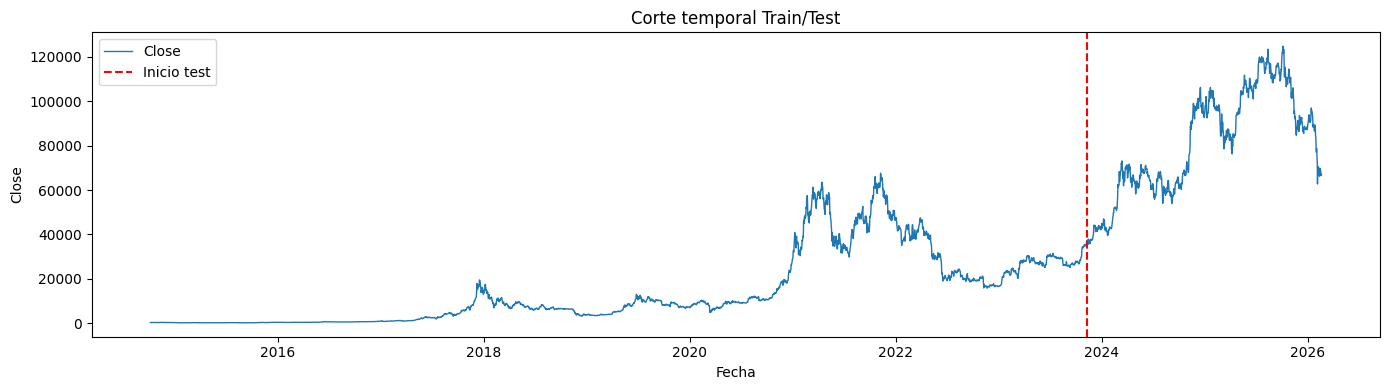

In [ ]:
target_dist = pd.DataFrame({
    "train_pct_target_1": [y_train.mean() * 100],
    "test_pct_target_1": [y_test.mean() * 100],
}).round(2)
display(target_dist)

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Close"], label="Close", linewidth=1)
plt.axvline(test_df.index.min(), color="red", linestyle="--", label="Inicio test")
plt.title("Corte temporal Train/Test")
plt.xlabel("Fecha")
plt.ylabel("Close")
plt.legend()
plt.tight_layout()
plt.show()


## Paso 6: Baseline y comparativa de modelos clasicos

Comparamos varios modelos sobre una validacion temporal interna tomada desde `train`.

> Control de leakage: en este paso no se usa `test` para seleccionar modelo.


In [34]:
# Split temporal interno dentro de train (para comparar modelos sin tocar test)
valid_size_within_train = 0.20
split_train_valid_idx = int(len(train_df) * (1 - valid_size_within_train))

train_sub_df = train_df.iloc[:split_train_valid_idx].copy()
valid_df = train_df.iloc[split_train_valid_idx:].copy()

X_train_sub = train_sub_df[feature_cols]
y_train_sub = train_sub_df[target_col]
X_valid = valid_df[feature_cols]
y_valid = valid_df[target_col]

print(f"Train_sub rows: {len(train_sub_df)} | Valid rows: {len(valid_df)}")
print(f"Train_sub period: {train_sub_df.index.min().date()} -> {train_sub_df.index.max().date()}")
print(f"Valid period:     {valid_df.index.min().date()} -> {valid_df.index.max().date()}")
print(f"No overlap temporal: {train_sub_df.index.max() < valid_df.index.min()}")


Train_sub rows: 2659 | Valid rows: 665
Train_sub period: 2014-10-06 -> 2022-01-15
Valid period:     2022-01-16 -> 2023-11-11
No overlap temporal: True


,model,roc_auc_valid,accuracy_valid
0,logistic_regression,0.515510,0.488722
1,gradient_boosting,0.510692,0.475188
2,baseline_dummy,0.500000,0.476692
3,random_forest,0.455591,0.461654


Mejor modelo en validacion temporal (ROC-AUC): logistic_regression


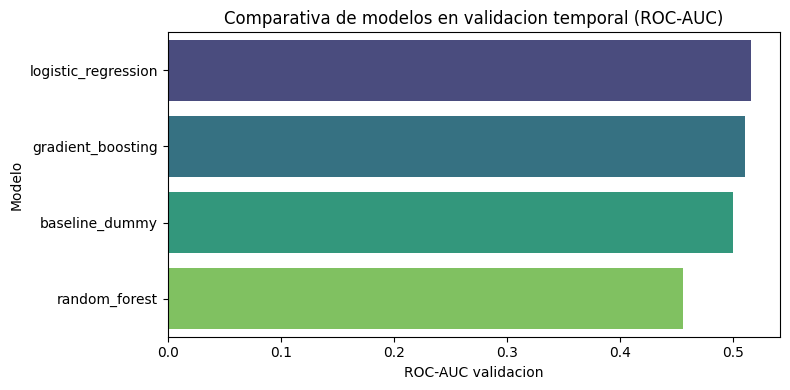

In [ ]:
# Baseline + modelos clasicos
from sklearn.dummy import DummyClassifier

candidate_models = {
    "baseline_dummy": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="prior")),
    ]),
    "logistic_regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "gradient_boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

results = []
fitted_models = {}

for model_name, model_pipeline in candidate_models.items():
    model_pipeline.fit(X_train_sub, y_train_sub)
    fitted_models[model_name] = model_pipeline

    y_valid_proba = model_pipeline.predict_proba(X_valid)[:, 1]
    y_valid_pred = (y_valid_proba >= 0.5).astype(int)

    results.append({
        "model": model_name,
        "roc_auc_valid": roc_auc_score(y_valid, y_valid_proba),
        "accuracy_valid": accuracy_score(y_valid, y_valid_pred),
    })

comparison_df = pd.DataFrame(results).sort_values("roc_auc_valid", ascending=False).reset_index(drop=True)
best_model_name = comparison_df.loc[0, "model"]

display(comparison_df)
print(f"Mejor modelo en validacion temporal (ROC-AUC): {best_model_name}")
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_df, x="roc_auc_valid", y="model", palette="viridis")
plt.title("Comparativa de modelos en validacion temporal (ROC-AUC)")
plt.xlabel("ROC-AUC validacion")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


## Paso 7: Optimizacion de hiperparametros con validacion cruzada temporal

Aplicamos `GridSearchCV` con `TimeSeriesSplit` sobre el conjunto de entrenamiento para mejorar modelos clasicos sin usar el test.

> Control de leakage: la optimizacion se realiza solo con `X_train` / `y_train`; el test queda reservado para evaluacion final.


,model,best_cv_roc_auc,best_params
0,logistic_regression,0.533566,"{'model__C': 0.01, 'model__class_weight': 'bal..."
1,random_forest,0.514605,"{'model__class_weight': None, 'model__max_dept..."
2,gradient_boosting,0.509666,"{'model__learning_rate': 0.1, 'model__max_dept..."


Mejor modelo tras tuning (CV ROC-AUC): logistic_regression


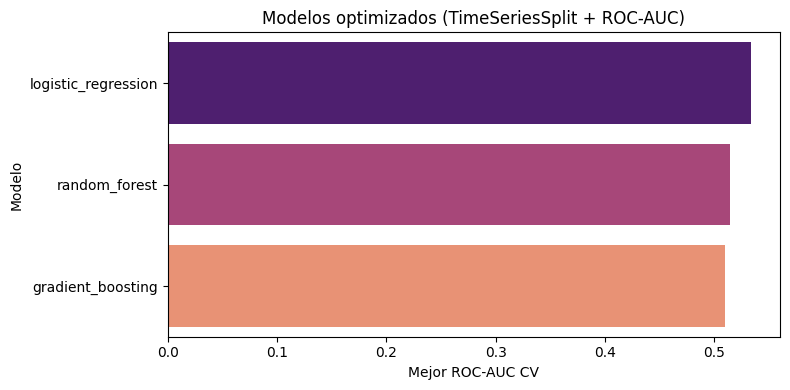

In [36]:
# Hiperparametros + validacion cruzada temporal (solo en train)
tuning_models = {
    "logistic_regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "gradient_boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

param_grids = {
    "logistic_regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs"],
        "model__class_weight": [None, "balanced"],
    },
    "random_forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 5, None],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced_subsample"],
    },
    "gradient_boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3],
    },
}

tscv = TimeSeriesSplit(n_splits=5)
grid_results = []
tuned_models = {}

for model_name, model_pipeline in tuning_models.items():
    grid = GridSearchCV(
        estimator=model_pipeline,
        param_grid=param_grids[model_name],
        scoring="roc_auc",
        cv=tscv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)

    tuned_models[model_name] = grid.best_estimator_
    grid_results.append({
        "model": model_name,
        "best_cv_roc_auc": grid.best_score_,
        "best_params": grid.best_params_,
    })

tuning_df = pd.DataFrame(grid_results).sort_values("best_cv_roc_auc", ascending=False).reset_index(drop=True)
best_tuned_model_name = tuning_df.loc[0, "model"]
best_tuned_model = tuned_models[best_tuned_model_name]

display(tuning_df)
print(f"Mejor modelo tras tuning (CV ROC-AUC): {best_tuned_model_name}")

plt.figure(figsize=(8, 4))
sns.barplot(data=tuning_df, x="best_cv_roc_auc", y="model", palette="magma")
plt.title("Modelos optimizados (TimeSeriesSplit + ROC-AUC)")
plt.xlabel("Mejor ROC-AUC CV")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


## Paso 8: Evaluacion final contra test

Evaluamos una sola vez en test para estimar rendimiento fuera de muestra y comparamos contra baseline.

> Control de leakage: el test no se usa para entrenar ni para ajustar hiperparametros.


In [38]:
# Baseline final (entrenado en train completo) vs modelo tuneado
from sklearn.dummy import DummyClassifier

# Umbral base simple para clasificacion
decision_threshold = 0.5

baseline_final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="prior")),
])
baseline_final_model.fit(X_train, y_train)

# Predicciones en test
y_test_proba_baseline = baseline_final_model.predict_proba(X_test)[:, 1]
y_test_pred_baseline = (y_test_proba_baseline >= decision_threshold).astype(int)

y_test_proba_final = best_tuned_model.predict_proba(X_test)[:, 1]
y_test_pred_final = (y_test_proba_final >= decision_threshold).astype(int)

test_results_df = pd.DataFrame([
    {
        "model": "baseline_dummy",
        "roc_auc_test": roc_auc_score(y_test, y_test_proba_baseline),
        "accuracy_test": accuracy_score(y_test, y_test_pred_baseline),
        "pct_pred_1_test": y_test_pred_baseline.mean() * 100,
    },
    {
        "model": f"best_tuned_{best_tuned_model_name}",
        "roc_auc_test": roc_auc_score(y_test, y_test_proba_final),
        "accuracy_test": accuracy_score(y_test, y_test_pred_final),
        "pct_pred_1_test": y_test_pred_final.mean() * 100,
    },
]).sort_values("roc_auc_test", ascending=False).reset_index(drop=True)

display(test_results_df.round(4))
print("Metrica principal: ROC-AUC")
print(f"Umbral usado en test: {decision_threshold:.2f}")


,model,roc_auc_test,accuracy_test,pct_pred_1_test
0,best_tuned_logistic_regression,0.5416,0.4898,0.2407
1,baseline_dummy,0.5000,0.5102,100.0000


Metrica principal: ROC-AUC
Umbral usado en test: 0.50


Classification report (modelo final):
              precision    recall  f1-score   support

           0     0.4897    0.9975    0.6570       407
           1     0.5000    0.0024    0.0047       424

    accuracy                         0.4898       831
   macro avg     0.4949    0.5000    0.3308       831
weighted avg     0.4950    0.4898    0.3242       831



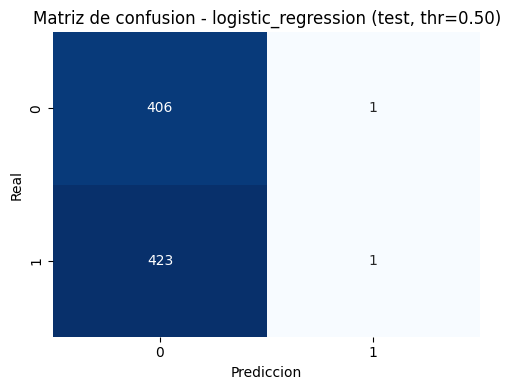

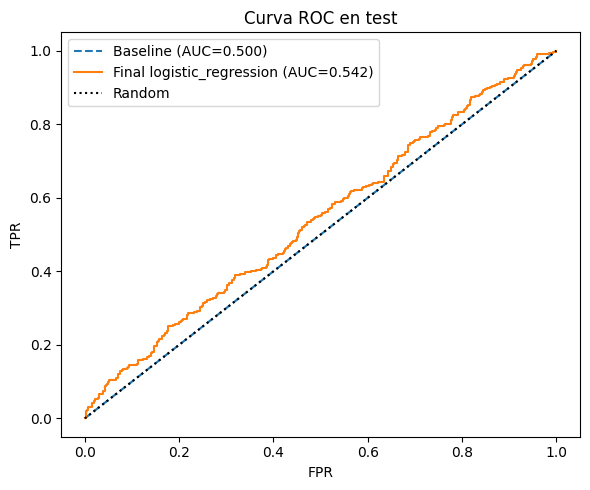

In [39]:
# Diagnostico del modelo final en test
print("Classification report (modelo final):")
print(classification_report(y_test, y_test_pred_final, digits=4))

cm = confusion_matrix(y_test, y_test_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Matriz de confusion - {best_tuned_model_name} (test, thr={decision_threshold:.2f})")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

fpr_base, tpr_base, _ = roc_curve(y_test, y_test_proba_baseline)
fpr_final, tpr_final, _ = roc_curve(y_test, y_test_proba_final)

auc_base = roc_auc_score(y_test, y_test_proba_baseline)
auc_final = roc_auc_score(y_test, y_test_proba_final)

plt.figure(figsize=(6, 5))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC={auc_base:.3f})", linestyle="--")
plt.plot(fpr_final, tpr_final, label=f"Final {best_tuned_model_name} (AUC={auc_final:.3f})")
plt.plot([0, 1], [0, 1], "k:", label="Random")
plt.title("Curva ROC en test")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.tight_layout()
plt.show()


## Paso 9: Persistencia del modelo

Guardamos el modelo final en formato `joblib` dentro de `src/models/`, tal como exige el enunciado.


In [40]:
# Guardado del modelo final en src/models
from pathlib import Path

MODELS_DIR = Path("src/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILENAME = f"btc_direction_{best_tuned_model_name}.joblib"
MODEL_PATH = MODELS_DIR / MODEL_FILENAME

joblib.dump(best_tuned_model, MODEL_PATH)

print(f"Modelo guardado en: {MODEL_PATH}")
print(f"Tamano del archivo (bytes): {MODEL_PATH.stat().st_size}")


Modelo guardado en: src/models/btc_direction_logistic_regression.joblib
Tamano del archivo (bytes): 2449


In [41]:
# Verificacion de carga del modelo guardado
loaded_model = joblib.load(MODEL_PATH)
sample_proba = loaded_model.predict_proba(X_test.head(5))[:, 1]

print("Modelo recargado correctamente.")
print("Probabilidades de ejemplo (5 primeras filas de test):")
print(np.round(sample_proba, 4))


Modelo recargado correctamente.
Probabilidades de ejemplo (5 primeras filas de test):
[0.4716 0.4756 0.4893 0.4303 0.4963]


## Conclusiones academicas

En esta seccion sintetizamos resultados, alcance y limites del proyecto con enfoque de evaluacion academica.


In [42]:
# Resumen numerico para conclusiones
final_row = test_results_df[test_results_df["model"].str.contains("best_tuned")].iloc[0]
baseline_row = test_results_df[test_results_df["model"] == "baseline_dummy"].iloc[0]

auc_final = float(final_row["roc_auc_test"])
auc_base = float(baseline_row["roc_auc_test"])
acc_final = float(final_row["accuracy_test"])
acc_base = float(baseline_row["accuracy_test"])

print(f"Modelo final seleccionado: {best_tuned_model_name}")
print(f"ROC-AUC test (final): {auc_final:.4f}")
print(f"ROC-AUC test (baseline): {auc_base:.4f}")
print(f"Mejora ROC-AUC vs baseline: {auc_final - auc_base:+.4f}")
print(f"Accuracy test (final): {acc_final:.4f}")
print(f"Accuracy test (baseline): {acc_base:.4f}")


Modelo final seleccionado: logistic_regression
ROC-AUC test (final): 0.5416
ROC-AUC test (baseline): 0.5000
Mejora ROC-AUC vs baseline: +0.0416
Accuracy test (final): 0.4898
Accuracy test (baseline): 0.5102


### Sintesis final

- **Problema resuelto**: se construyo un clasificador binario para estimar la probabilidad de cierre positivo de Bitcoin al dia siguiente.
- **Metrica principal**: se priorizo **ROC-AUC** por ser una metrica robusta para comparar capacidad discriminativa probabilistica sin fijar umbral.
- **Resultado clave**: el modelo final optimizado supero al baseline en test (ver celda anterior), validando que aporta senal predictiva adicional.
- **Rigor metodologico**: se aplico split temporal, validacion cruzada con `TimeSeriesSplit` y control explicito de riesgo de data leakage.
- **Limitaciones**: el modelo usa solo variables OHLCV; no incorpora contexto macro, on-chain ni costes de transaccion.
- **Mejoras futuras concretas**: ingenieria de variables temporales (lags, retornos y volatilidad rolling), calibracion/umbral en validacion temporal y evaluacion walk-forward.
